# Real-world terrains fetched with earthlens

Three real elevation datasets, each fetched once with
[earthlens](https://github.com/serapeum-org/earthlens) and committed as a small fixture so this notebook
runs offline — a mountain, a canyon, and an ocean trench:

| region | dataset | relief |
|---|---|---|
| **Mont Blanc** (Alps) | Copernicus DEM GLO-30 | 792 → 4808 m |
| **Grand Canyon** (USA) | Copernicus DEM GLO-30 | 695 → 2804 m |
| **Mariana Trench** (Pacific) | GEBCO 2020 bathymetry | −10952 → −2063 m |

*Copernicus WorldDEM-30 © DLR/Airbus, provided under Copernicus by the EU/ESA. GEBCO Compilation Group
(2020), GEBCO 2020 Grid, doi:10.5285/a29c5465-b138-234d-e053-6c86abc040b9.*

---
*Data.* All layers below are built from **real data downloaded with
[earthlens](https://github.com/serapeum-org/earthlens)** and committed as small fixtures under
`examples/data/`; vector and 3-D layers are derived from those real rasters through **pyramids** (the GIS
engine), so nothing here is synthetic. Attributions are given per dataset.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

import pyramids  # import first: bootstraps pyramids' vendored GDAL
from pyramids.dataset import Dataset
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'real_dem_mont_blanc.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

## How the fixtures were produced (guarded — only runs if missing)

earthlens is **not** a Digital-Earth dependency, so this cell only runs when a tile is absent (it needs
`earthlens-land[dem]` installed). In CI the fixtures are present, so the downloads are skipped.

In [2]:
def fetch_cop_dem(out_name, lat_lim, lon_lim):
    """Fetch + crop a Copernicus DEM GLO-30 tile with earthlens, only if the fixture is missing."""
    out = DATA / out_name
    if out.exists():
        return out
    from earthlens.core import EarthLens
    from pyramids.dataset.merge import merge_rasters
    tiles = EarthLens(data_source='dem', dataset='cop-dem-glo-30',
                      lat_lim=lat_lim, lon_lim=lon_lim, path=str(DATA / '_dl')).download()
    merged = str(DATA / '_merged.tif')
    merge_rasters([str(t) for t in tiles], merged)
    ds = Dataset.read_file(merged)
    bbox = [lon_lim[0], lat_lim[0], lon_lim[1], lat_lim[1]]
    ds.crop(bbox=bbox, epsg=4326).resample(0.0007, method='bilinear').to_file(str(out))
    return out

for name in ('real_dem_mont_blanc.tif', 'real_dem_grand_canyon.tif', 'real_bathymetry.tif'):
    print(name, '->', (DATA / name).exists())

real_dem_mont_blanc.tif -> True
real_dem_grand_canyon.tif -> True
real_bathymetry.tif -> True


## Mont Blanc — the summit above the Chamonix valley

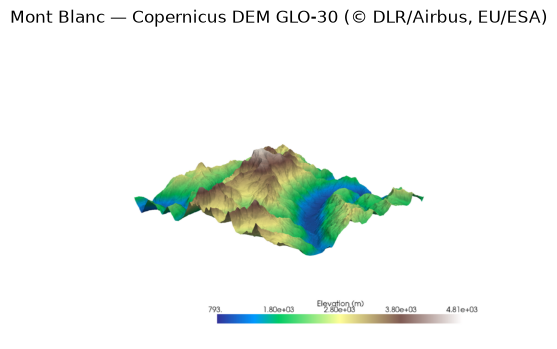

In [3]:
scene = Scene3D(off_screen=True)
scene.terrain(Dataset.read_file(str(DATA / 'real_dem_mont_blanc.tif')), z_exaggeration=2.0, cmap='terrain')
scene.colorbar(label='Elevation (m)')
scene.view('isometric')
show(scene, 'Mont Blanc — Copernicus DEM GLO-30 (© DLR/Airbus, EU/ESA)')
scene.close()

## Grand Canyon — incised plateau relief

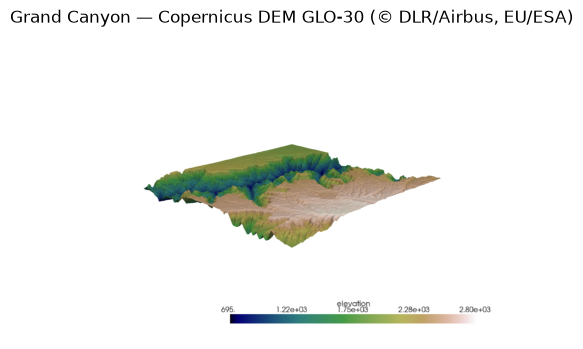

In [4]:
scene = Scene3D(off_screen=True)
scene.terrain(Dataset.read_file(str(DATA / 'real_dem_grand_canyon.tif')), z_exaggeration=2.0, cmap='gist_earth')
scene.view('isometric')
show(scene, 'Grand Canyon — Copernicus DEM GLO-30 (© DLR/Airbus, EU/ESA)')
scene.close()

## Mariana Trench — the deepest sea floor on Earth

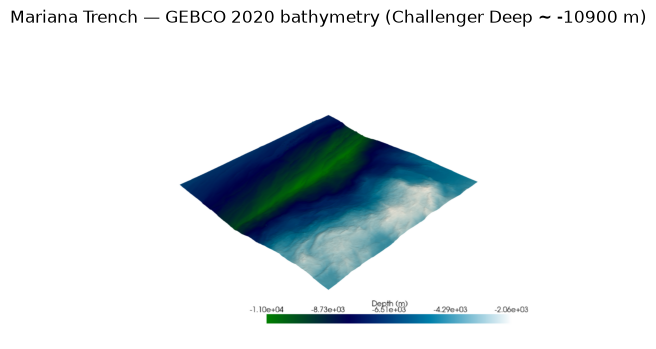

In [5]:
scene = Scene3D(off_screen=True)
scene.terrain(Dataset.read_file(str(DATA / 'real_bathymetry.tif')), z_exaggeration=1.0, cmap='ocean')
scene.colorbar(label='Depth (m)')
scene.view('isometric')
show(scene, 'Mariana Trench — GEBCO 2020 bathymetry (Challenger Deep ~ -10900 m)')
scene.close()